In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

#Data 
df = pd.read_csv('car_fuel_efficiency_2026.csv', usecols=["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"])
df.columns.str.lower().str.replace(' ', '_')

Index(['model_year', 'engine_displacement', 'horsepower', 'vehicle_weight',
       'fuel_efficiency_mpg'],
      dtype='str')

In [2]:
#Question 1
#There's one column with missing values. What is it?
df.isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

In [3]:
#Question 2
#What's the median (50% percentile) for variable 'horsepower'?
df['horsepower'].median()

np.float64(254.0)

In [4]:
#Shuffling and spliting
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [13]:
#Question 3
#We need to deal with missing values for the column from Q1.
#We have two options: fill it with 0 or with the mean of this variable.
#Try both options. For each, train a linear regression model without regularization using the code from the lessons.
#for computing the mean, use the training only!
#Use the validation dataset to evaluate the models and compare the RMSE of each option.
#Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
#Which option gives better RMSE?

def dot(xi, w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + w[j]*xi[j]
    return res

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0]) #Cria uma matrix so de 1 com o tamanho n x 1. Onde n é o numero de linhas de X (X.shape[0])
    X = np.column_stack([ones, X]) #Concatena o X na matriz de 1's

    XTX = X.T.dot(X) #Calcula o X*Xtransposta
    XTX_inv = np.linalg.inv(XTX) #Calcula a inversa
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y-y_pred) ** 2
    mse = se.mean()
    return round(np.sqrt(mse), 3)

def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    #Preparing feature engineering data "age of the car" -> (Max year - model year = age)
    df['age'] = 2024 - df.model_year
    features.append('age')
    
    #Preparing Categorical variables. Applying weight to the values
#    for v in [2, 3, 4]:
#       df['num_doors_%s' % v] = (df.num_doors == v).astype('int') #%s is changed to the 'v' number; the '==' means the boolean comparison and astype('int') transform it in number
#        features.append('num_doors_%s' % v)

#    for c, values in categories.items():
#        for v in values:
#            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
#            features.append('%s_%s' % (x, v))
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

df.dtypes #Verifica os tipos pra ver quais variaveis eu vou usar no treinamento
df_train.columns #Lista os nomes das colunas pra facilitar o ctrl c ctrl v no "base"
base = ['engine_displacement', 'horsepower', 'vehicle_weight']
#categorical_variables = ['origin', 'fuel_type', 'drivetrain', 'vehicle_weight', 'acceleration']
y = ['fuel_efficiency_mpg']
y_train = df_train[y].values

#categories = {}
#for c in categorical_variables:
#    categories[c] = list(df[c].value_counts().head().index)

In [14]:
prepare_X(df)

array([[2180.,  243., 3870.,   18.],
       [2390.,  272., 4210.,   16.],
       [2320.,  267., 4240.,   28.],
       ...,
       [2480.,  267., 4590.,   10.],
       [2180.,  270., 4450.,   20.],
       [2380.,  295., 4370.,   13.]], shape=(10000, 4))

In [15]:
#Testando a substituição de NaN com 0s

X_train_zeros = df_train[base].fillna(0).values #Monta a matriz X!!!
#X_train_mean = df_train[base].fillna(df['horsepower'].mean())

w0_zeros, w_zeros = train_linear_regression(X_train_zeros, y_train)
#w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

y_pred_zeros = w0_zeros + X_train_zeros.dot(w_zeros)
#y_pred_mean = w0_mean + X_train_mean.dot(w_mean)

In [19]:
rmse(y_train, y_pred_zeros)

np.float64(2.592)

<Axes: ylabel='Count'>

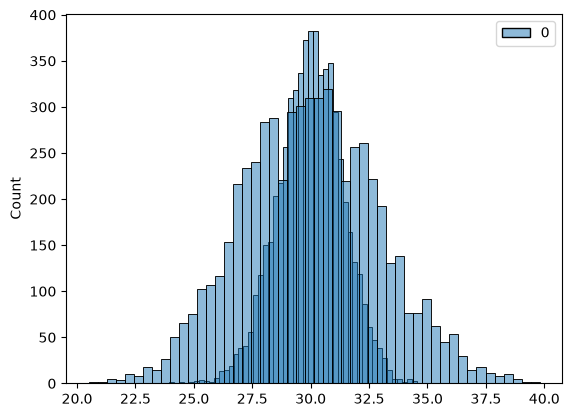

In [17]:
sns.histplot(y_pred_zeros, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [ ]:
#Question 4
#Now let's train a regularized linear regression.
#For this question, fill the NAs with 0.
#ry different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
#Use RMSE to evaluate the model on the validation dataset.
#Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
#Which r gives the best RMSE?
